# Composite noise model — DZNE & PEC

Composite **hardware** noise model = **ThermalRealistic ∘ MixedUnitary** (biased Pauli channel),
benchmarked with **Digital ZNE** and **PEC** over 20 mirror-circuit seeds. Built on the `qem/`
package and mirroring the methodology of [DZNE_VS_PEC_mitiq.ipynb](DZNE_VS_PEC_mitiq.ipynb).

**Why no separate depolarizing channel?** MixedUnitary is a *biased Pauli* channel
$D(\varepsilon) = (1-\varepsilon)[I] + \varepsilon\big(\tfrac{\eta}{\eta+1}Z + \tfrac{1}{3(\eta+1)}(X+Y+Z)\big)$.
Its symmetric term $\tfrac{1}{3(\eta+1)}(X+Y+Z)$ **is** a depolarizing channel ($\eta=0\Rightarrow$
pure depolarizing); $\eta=4$ just adds the extra $Z$ (dephasing) bias. So MixedUnitary **already
contains** the depolarizing component — adding a standalone `depolarizing_error` would double-count
the isotropic Pauli error. The composite therefore stacks only the two physically-distinct
mechanisms: incoherent T1/T2 relaxation **+** the biased-Pauli calibration residual.

## 1. Setup

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from mitiq import zne
from mitiq.zne.scaling import fold_global
from mitiq.zne.inference import RichardsonFactory, PolyFactory, ExpFactory, AdaExpFactory

# All project machinery lives in the qem/ package. Make it importable regardless of
# the kernel working directory:
import sys
from pathlib import Path
for _cand in (Path.cwd(), Path.cwd() / "notebooks", *Path.cwd().parents):
    if (_cand / "qem" / "__init__.py").exists():
        if str(_cand) not in sys.path:
            sys.path.insert(0, str(_cand))
        break
from qem import *

print("qem loaded. Composite spec:", SPEC_COMPOSITE.name)

qem loaded. Composite spec: Composite


## 2. Composite model

Per **physical** gate (`sx`, `sxdg`, `x`, `h`, `cx`) two Aer `QuantumError`s are composed into a
single channel:

1. `thermal_relaxation_error(T1, T2, gate_time)` — each gate relaxes in proportion to its duration
   (T1 = 100 µs, T2 = 80 µs; `cx` ~400 ns is the dominant relaxation). **Non-unital** → the state
   drifts toward $|0\dots0\rangle$.
2. `pauli_error(...)` — the biased-Pauli MixedUnitary kick ($\varepsilon_{1q}=10^{-3}$,
   $\varepsilon_{2q}=5\cdot10^{-3}$, $\eta=4$).

`rz` / `id` are **virtual** (zero duration, $\varepsilon=0$) → **no noise**, consistent with both
parent models.

Because the non-unital thermal part makes the per-seed $P(|00\rangle)$ fixed point vary, we use
`asymptote=None` (3-parameter free Exp/AdaExp fit) with 5 scale factors $[1, 1.5, 2, 3, 5]$
(≥4 points are required for the free fit).

In [2]:
from qem.noise_models import T1_S, T2_S, GATE_TIME_S, EPS_MU_1Q, EPS_MU_2Q, ETA_MU

_nm = SPEC_COMPOSITE.build_noise_model()
composite_backend = AerSimulator(noise_model=_nm)
ideal_backend     = AerSimulator()

print("Composite = ThermalRealistic (T1/T2) + MixedUnitary (biased Pauli)")
print(f"  Thermal : T1={T1_S*1e6:.0f} us  T2={T2_S*1e6:.0f} us  "
      f"gate_times(ns)={ {g: int(t*1e9) for g, t in GATE_TIME_S.items()} }")
print(f"  MixedU  : eps_1q={EPS_MU_1Q}  eps_2q={EPS_MU_2Q}  eta={ETA_MU}")
print(f"  Noised physical gates : {sorted(_nm.noise_instructions)}  (rz/id virtual -> none)")
print(f"  asymptote={SPEC_COMPOSITE.asymptote}  "
      f"scale_factors={SPEC_COMPOSITE.scale_factors}  N_SEEDS={N_SEEDS}")

Composite = ThermalRealistic (T1/T2) + MixedUnitary (biased Pauli)
  Thermal : T1=100 us  T2=80 us  gate_times(ns)={'rz': 0, 'id': 0, 'sx': 35, 'sxdg': 35, 'x': 35, 'h': 35, 'cx': 400}
  MixedU  : eps_1q=0.001  eps_2q=0.005  eta=4.0
  Noised physical gates : ['cx', 'h', 'sx', 'sxdg', 'x']  (rz/id virtual -> none)
  asymptote=None  scale_factors=[1.0, 1.5, 2.0, 3.0, 5.0]  N_SEEDS=20


## 3. Noisy baseline (20 seeds)

Pauli-randomized **mirror circuits** (Proctor et al., PRL 2022): random Clifford layers and their
inverse with inserted random Pauli layers, so the ideal outcome is a known bitstring
(P(success)=1). First an ideal sanity check (each seed returns its own target ~1.0 — catches any
bitstring/endianness bug), then the composite noisy baseline.

Ideal (seeds 0..4): ['1.0000', '1.0000', '1.0000', '1.0000', '1.0000']
Targets           : ['01', '01', '00', '00', '00']
Computing composite noisy baseline...
P(success) noisy -- mean=0.8559  std=0.0290  bias=-0.1441


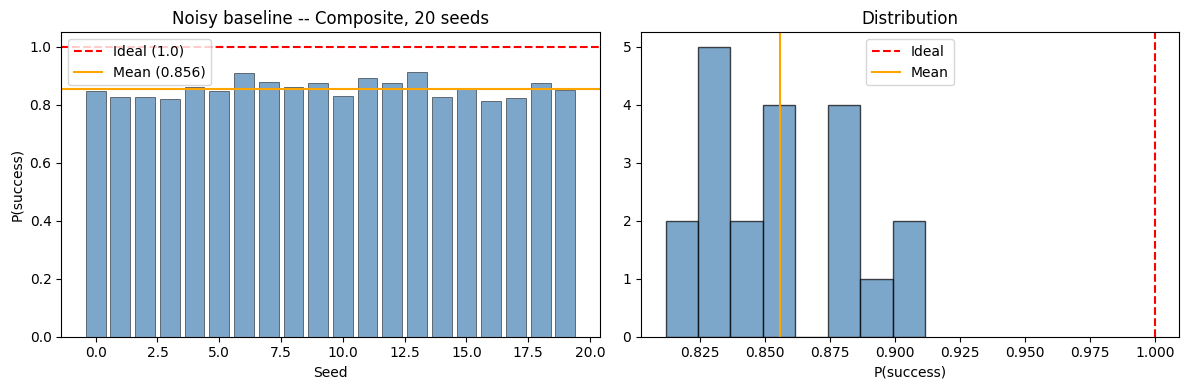

In [3]:
# Ideal validation: each seed's mirror returns its OWN target bitstring w.p. ~1.0.
ideal_spot = [success_prob(ideal_backend, s) for s in range(5)]
print("Ideal (seeds 0..4):", [f"{v:.4f}" for v in ideal_spot])
print("Targets           :", [target_key(s) for s in range(5)])
assert all(v > 0.99 for v in ideal_spot), "Mirror target/endianness mismatch!"

print("Computing composite noisy baseline...")
noisy_vals = np.array([success_prob(composite_backend, s) for s in SEEDS])
print(f"P(success) noisy -- mean={noisy_vals.mean():.4f}  std={noisy_vals.std():.4f}  "
      f"bias={noisy_vals.mean() - IDEAL:+.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.bar(SEEDS, noisy_vals, color="steelblue", alpha=0.7, edgecolor="black", linewidth=0.5)
ax1.axhline(IDEAL, color="red", ls="--", lw=1.5, label=f"Ideal ({IDEAL:.1f})")
ax1.axhline(noisy_vals.mean(), color="orange", ls="-", lw=1.5,
            label=f"Mean ({noisy_vals.mean():.3f})")
ax1.set_xlabel("Seed"); ax1.set_ylabel("P(success)")
ax1.set_title("Noisy baseline -- Composite, 20 seeds"); ax1.legend()
ax2.hist(noisy_vals, bins=8, color="steelblue", alpha=0.7, edgecolor="black")
ax2.axvline(IDEAL, color="red", ls="--", lw=1.5, label="Ideal")
ax2.axvline(noisy_vals.mean(), color="orange", ls="-", lw=1.5, label="Mean")
ax2.set_xlabel("P(success)"); ax2.set_title("Distribution"); ax2.legend()
plt.tight_layout(); plt.show()

## 4. DZNE vs PEC benchmark — 20 seeds (equal shot budget)

A single `cached_benchmark(SPEC_COMPOSITE)` call produces the noisy baseline, the four ZNE methods
(Richardson, Poly2, Exp, AdaExp) **and PEC** on the same 20 seeds at **equal shot budget**, so MSE
gaps reflect the *method*, not the budget. Metrics: **bias**, **variance**, **MSE = bias² + variance**.

**PEC representations** (`SPEC_COMPOSITE.build_representations`): the per-qubit composite noise channel
is lifted **straight from the Aer `QuantumError`** (`Kraus(thermal ∘ mu_pauli)`), so the PEC
basis-noise matches the simulated noise to machine precision. Physical 1q gates (sx/sxdg/x/h) and CX
(both orientations) use the Pauli+reset LP; virtual `rz`/`id` (no noise) get an exact identity rep.
The CX channel $(\text{th}\otimes\text{th})\circ(\mu\otimes\mu)$ factorizes as
$(\text{th}\circ\mu)\otimes(\text{th}\circ\mu)$ (verified to $10^{-16}$), so one per-qubit Kraus drives it.

> These reps are **exact** — they reconstruct the Aer channels to $\sim10^{-7}$, so PEC is **unbiased**
> (bias $\approx +0.004$, $\gamma\approx1.6$). An earlier apparent "$+0.06$ bias" was an **artefact of a
> fixed `seed_simulator`**: reusing one noise RNG stream across PEC's thousands of importance samples
> correlated them and biased the estimator (it also inflated the variance). `run_benchmark` now uses a
> **single seedless backend for all methods** — every method faces independent noise on the same
> footing, which removes the PEC bias, cuts its variance ~25×, and makes PEC competitive with the
> exponential ZNE fits. (Full diagnosis: `smoke_composite_pec_*.py`.)

In [4]:
df_comp, raw_comp, gammas_comp = cached_benchmark(SPEC_COMPOSITE, seeds=SEEDS)
print(f"\nMean PEC overhead (gamma_circuit) : {gammas_comp.mean():.3f}   max : {gammas_comp.max():.3f}")

[Composite]  seeds=20  asymptote=None  scale_factors=[1.0, 1.5, 2.0, 3.0, 5.0]
  shot_budget=30,000/circuit/method  ->  ZNE 6000x5, AdaExp 7500x4, PEC 3000 samples x 10 shots
  seed 5/20 done
  seed 10/20 done
  seed 15/20 done
  seed 20/20 done
  [warn] AdaExp: extrapolation failed on 3/20 seeds -> stats over the 17 that converged
                        mean     bias  variance      mse  n_fail  gamma_pec_mean
noise     method                                                                
Composite Noisy       0.8553 -0.14472   0.00091  0.02185       0             NaN
          Richardson  0.5625 -0.43750   0.39504  0.58645       0             NaN
          Poly2       0.9945 -0.00549   0.00024  0.00027       0             NaN
          Exp         1.0081  0.00810   0.00028  0.00034       0             NaN
          AdaExp      0.9955 -0.00452   0.00011  0.00013       3             NaN
          PEC         0.9962 -0.00376   0.00020  0.00021       0           1.595

[cache] saved 'Co

C:\Users\thoma\AppData\Local\Temp\ipykernel_20860\4260001347.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_plot, labels=labels_all, patch_artist=True)


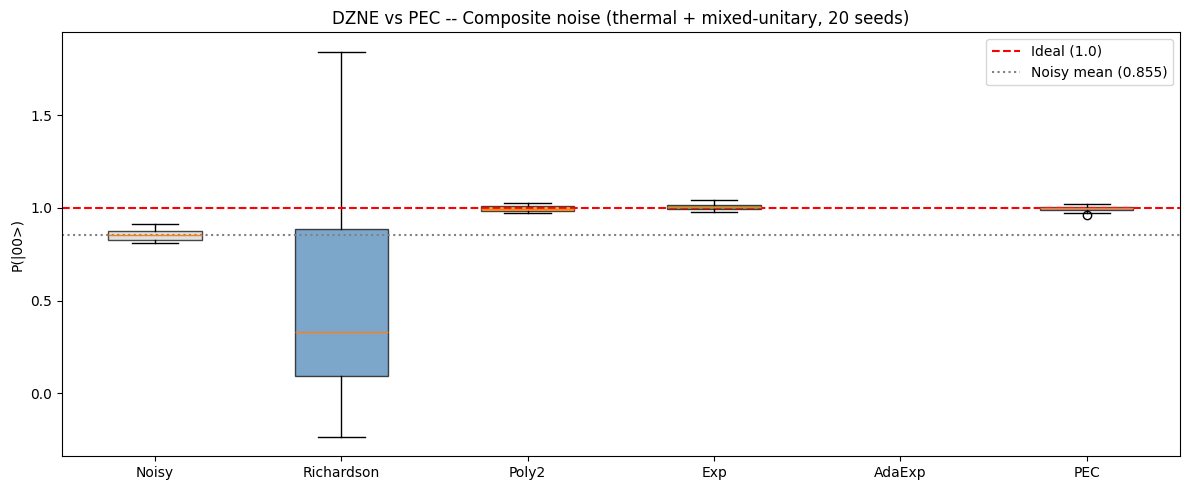

In [5]:
# Boxplot: per-method distribution (ZNE methods + PEC)
labels_all = ["Noisy", "Richardson", "Poly2", "Exp", "AdaExp", "PEC"]
colors_all = ["lightgray", "steelblue", "darkorange", "seagreen", "tomato", "mediumpurple"]
data_plot  = [np.asarray(raw_comp[k], dtype=float) for k in labels_all]
noisy_mean = data_plot[0].mean()

fig, ax = plt.subplots(figsize=(12, 5))
bp = ax.boxplot(data_plot, labels=labels_all, patch_artist=True)
for patch, color in zip(bp["boxes"], colors_all):
    patch.set_facecolor(color); patch.set_alpha(0.7)
ax.axhline(IDEAL, color="red", ls="--", lw=1.5, label=f"Ideal ({IDEAL})")
ax.axhline(noisy_mean, color="gray", ls=":", lw=1.5, label=f"Noisy mean ({noisy_mean:.3f})")
ax.set_ylabel("P(|00>)")
ax.set_title(f"DZNE vs PEC -- Composite noise (thermal + mixed-unitary, {N_SEEDS} seeds)")
ax.legend()
plt.tight_layout(); plt.show()

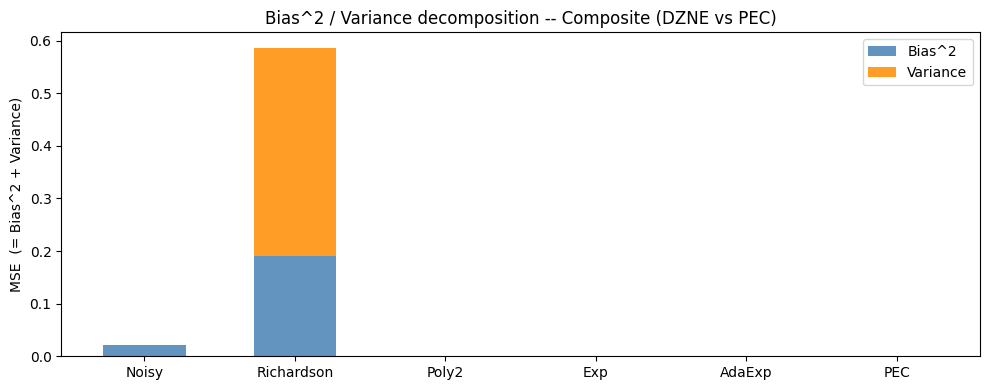

In [6]:
# Bias^2 / Variance decomposition
methods_plot = ["Noisy", "Richardson", "Poly2", "Exp", "AdaExp", "PEC"]
bias2_vals   = [df_comp.loc[("Composite", m), "bias"] ** 2 for m in methods_plot]
var_vals     = [df_comp.loc[("Composite", m), "variance"]  for m in methods_plot]

x = np.arange(len(methods_plot)); width = 0.55
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x, bias2_vals, width, label="Bias^2",   color="steelblue",  alpha=0.85)
ax.bar(x, var_vals,   width, label="Variance", color="darkorange", alpha=0.85, bottom=bias2_vals)
ax.set_xticks(x); ax.set_xticklabels(methods_plot)
ax.set_ylabel("MSE  (= Bias^2 + Variance)")
ax.set_title("Bias^2 / Variance decomposition -- Composite (DZNE vs PEC)")
ax.legend()
plt.tight_layout(); plt.show()

### Summary

Under this realistic composite noise (noisy bias ≈ −0.14), the **DZNE exponential extrapolators**
(`Exp`, `AdaExp`) and `Poly2` recover P(success) ≈ 1 (bias ≈ 0 at low variance), while `Richardson`
is penalized by its Runge-prone polynomial extrapolation over the wide λ range.

**PEC** inverts the *exact* per-gate composite channel (basis-noise lifted straight from the Aer
`QuantumError`, matching the simulation to ~10⁻⁷) at low overhead (γ ≈ 1.6), and is **unbiased**
(bias ≈ +0.004) — competitive with the exponential ZNE fits. Both families work well here; PEC's
edge would show on stronger / more structured noise where extrapolation breaks down.

> **Methodology note / bug fix.** An earlier version showed PEC biased by ≈ +0.06. The reps were
> never at fault (they reconstruct the Aer channels to 10⁻⁷); the bias was an artefact of a **fixed
> `seed_simulator`** shared across PEC's thousands of importance samples, which correlated the noise
> realisations and biased the estimator. `run_benchmark` now uses a **single seedless backend for all
> methods** (uniform benchmark — every method sees independent noise) → unbiased PEC and ~25× lower
> variance. The diagnosis is traced in the `smoke_composite_pec_*.py` scripts (per-gate exactness,
> executor comparison, repeat-variance, few-shots, and the seed-fix verification).